In [1]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin

In [2]:
#function
#ABS
def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))

    #if max_err > check_tol:
    #    mag = np.abs(eigvals)
    #    print("Sorted |eigvals|:", np.sort(mag))
    #    raise RuntimeError(
    #        fr"Self-consistency violated: max |Δ| = {max_err}"
    #    )
    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD_quan(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, E, eta=1e-6):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(E + 1j*eta)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E + 1j*eta)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    g_ii = [np.zeros((d, d), dtype=complex) for _ in range(N)]

    d_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]#第一个是0
    for i in range(N-1,-1,-1):
        if i==N-1:
            d_R[i]=A_DD[i][i]
        else:
            c_R[i+1]=-1*A_DD[i][i+1] @ np.linalg.inv(d_R[i+1])
            d_R[i]=A_DD[i][i]+c_R[i+1] @ A_DD[i+1][i]

    d_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]#最后一个是0

    for i in range(N):
        if i==0:
            d_L[i]=A_DD[i][i]
        else:
            c_L[i-1]=-1*A_DD[i][i-1] @ np.linalg.inv(d_L[i-1])
            d_L[i]=A_DD[i][i]+ c_L[i-1] @ A_DD[i-1][i]

        g_ii[i]=np.linalg.inv(-A_DD[i][i]+d_L[i]+d_R[i])

    G_DD_r = [[Z.copy() for _ in range(N)] for _ in range(N)]
    for i in range(N):
        for j in range(N):

            if i == j:
                G_DD_r[i][j] = g_ii[i]

            elif i > j:
                prod = np.eye(d, dtype=complex)
                for k in range(i-1, j-1, -1):
                    prod = prod @ c_L[k]
                G_DD_r[i][j] = g_ii[i] @ prod


            else:  
                prod = np.eye(d, dtype=complex)
                for k in range(i+1, j+1):
                    prod = prod @ c_R[k]
                G_DD_r[i][j] = g_ii[i] @ prod

    G_DD_r = np.block(G_DD_r)
    A_DD = np.block(A_DD)
    return G_DD_r , A_DD , Sigma_R , Sigma_L 

def Gr_DD_kuaisanjiao(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, E, eta=3e-6):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(E + 1j*eta)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E + 1j*eta)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    g_ii = [np.zeros((d, d), dtype=complex) for _ in range(N)]

    d_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]#第一个是0
    for i in range(N-1,-1,-1):
        if i==N-1:
            d_R[i]=A_DD[i][i]
        else:
            c_R[i+1]=-1*A_DD[i][i+1] @ np.linalg.inv(d_R[i+1])
            d_R[i]=A_DD[i][i]+c_R[i+1] @ A_DD[i+1][i]

    d_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]#最后一个是0

    for i in range(N):
        if i==0:
            d_L[i]=A_DD[i][i]
        else:
            c_L[i-1]=-1*A_DD[i][i-1] @ np.linalg.inv(d_L[i-1])
            d_L[i]=A_DD[i][i]+ c_L[i-1] @ A_DD[i-1][i]

        g_ii[i]=np.linalg.inv(-A_DD[i][i]+d_L[i]+d_R[i])

    G_DD_r = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):
        G_DD_r[i][i] = g_ii[i]

    for i in range(N-1):
        G_DD_r[i][i+1] = g_ii[i] @ c_R[i+1]


    for i in range(N-1):
        G_DD_r[i+1][i] = g_ii[i+1] @ c_L[i]

    G_DD_r = np.block(G_DD_r)
    A_DD = np.block(A_DD)
    return G_DD_r , A_DD , Sigma_R , Sigma_L 

def Gr_DD(H_q,H_l,H_r,  T_12,T_LD,T_l,T_RD,T_r,  N,E,eta=3e-6):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(E + 1j*eta)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E + 1j*eta)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T
    A_DD = np.block(A_DD)
    G_DD_r = np.linalg.inv(A_DD)
    return G_DD_r , A_DD ,Sigma_R ,Sigma_L 
    
def bufeng(G_DD_r):
    d = H_q.shape[0]
    yigeshu=np.trace(G_DD_r[q*d:(q+1)*d, (q)*d:(q+1)*d])
    return -np.imag(yigeshu)/np.pi

def find_peaks_fmin(A_of_E, E_min, E_max, N_guess=11, xtol=1e-6, ftol=1e-6, round_digits=6):

    E_guesses = np.linspace(E_min, E_max, N_guess)
    peak_list = []

    for E0 in E_guesses:
        r = fmin(lambda E: -A_of_E(E), E0, disp=False, xtol=xtol, ftol=ftol)
        peak_list.append(r[0])

    peak_list = np.unique(np.round(peak_list, round_digits))
    return peak_list


#current1
def Gr_DD_MS_quan(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, wn):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(1j*wn)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (1j*wn)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    g_ii = [np.zeros((d, d), dtype=complex) for _ in range(N)]

    d_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]#第一个是0
    for i in range(N-1,-1,-1):
        if i==N-1:
            d_R[i]=A_DD[i][i]
        else:
            c_R[i+1]=-1*A_DD[i][i+1] @ np.linalg.inv(d_R[i+1])
            d_R[i]=A_DD[i][i]+c_R[i+1] @ A_DD[i+1][i]

    d_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]#最后一个是0

    for i in range(N):
        if i==0:
            d_L[i]=A_DD[i][i]
        else:
            c_L[i-1]=-1*A_DD[i][i-1] @ np.linalg.inv(d_L[i-1])
            d_L[i]=A_DD[i][i]+ c_L[i-1] @ A_DD[i-1][i]

        g_ii[i]=np.linalg.inv(-A_DD[i][i]+d_L[i]+d_R[i])


    G_DD_r = [[Z.copy() for _ in range(N)] for _ in range(N)]
    for i in range(N):
        for j in range(N):

            if i == j:
                G_DD_r[i][j] = g_ii[i]

            elif i > j:
                prod = np.eye(d, dtype=complex)
                for k in range(i-1, j-1, -1):
                    prod = prod @ c_L[k]
                G_DD_r[i][j] = g_ii[i] @ prod


            else:  
                prod = np.eye(d, dtype=complex)
                for k in range(i+1, j+1):
                    prod = prod @ c_R[k]
                G_DD_r[i][j] = g_ii[i] @ prod


    G_DD_wn = np.block(G_DD_r)
    A_DD_wn = np.block(A_DD)
    return G_DD_wn , A_DD_wn , Sigma_R , Sigma_L 

def Gr_DD_MS(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, wn):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(1j*wn)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (1j*wn)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    A_DD_wn = np.block(A_DD)
    G_DD_wn = np.linalg.inv(A_DD_wn)
    return G_DD_wn , A_DD_wn , Sigma_R , Sigma_L 

def Gr_DD_MS_gaiyixia(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, wn):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(1j*wn)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (1j*wn)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    A_DD_wn = np.block(A_DD)
    G_DD_wn = np.linalg.inv(A_DD_wn)
    f_E= 1/(1+np.exp((1j*wn - mu)/KBT))
    G_DD_wn_xiao=f_E*(G_DD_wn.conj()-G_DD_wn)
    return G_DD_wn_xiao , A_DD_wn , Sigma_R , Sigma_L 

def J_wn(G_DD_wn, T_12, q):
    d = T_12.shape[0]

    G_q_q1 = G_DD_wn[q*d:(q+1)*d, (q+1)*d:(q+2)*d]
    G_q1_q = G_DD_wn[(q+1)*d:(q+2)*d, q*d:(q+1)*d]

    Jmat = T_12.conj().T @ G_q1_q - G_q_q1 @ T_12
    d_e = d //2
    return np.trace(Jmat[:d_e, :d_e])*(-1j)*KBT
    #return np.trace(Jmat)*(-1j)*KBT

def matsubara_list(shumu):
    n_max =  shumu
    n_vals = np.arange(-n_max, n_max+1 )
    wn = (2 * n_vals + 1) * np.pi * KBT

    return wn.tolist()

def J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N, q):
    wn_list = matsubara_list(shumu)
    J_sum = 0.0 
    for wn in wn_list:
        G_DD_wn, _, _, _ = Gr_DD_MS_gaiyixia(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, wn
        )

        J_sum += np.real(J_wn(G_DD_wn, T_12, q))
    return (J_sum)


#current2
def JoseCurrent(H_l,H_r,H_q,T_l,T_r,T_12,T_RD,T_LD):
    H_L = H_l
    H_R = H_r
    H_D = H_q

    T_L = T_l
    T_R = T_r
    T_D = T_12
    T_DR = T_RD
    T_DL = T_LD

    lx = Lx // 2

    # temperature
   

    kBT = KBT
    mmax = shumu

    current = 0
    N = H_D.shape[0]

    for m in range(-(mmax + 1), mmax + 1):

        ef = 1j * (2*m + 1) * np.pi * kBT
        #EE = (ef + 1j*1e-6) * np.eye(N)
        EE = (ef ) * np.eye(N)
        # ================= Right Lead =================
        inv_TR = np.linalg.inv(T_R)

        TT_R = np.block([
            [inv_TR @ (EE - H_R), -inv_TR @ T_R.conj().T],
            [np.eye(N), np.zeros((N, N))]
        ])

        eigval, eigvec = np.linalg.eig(TT_R)
        idx = np.argsort(np.abs(eigval))

        v = eigvec[:, idx]
        S1 = v[:N, :N]
        S2 = v[N:2*N, :N]

        g_R = np.linalg.inv(
            EE - H_R - T_R @ S1 @ np.linalg.inv(S2)
        )

        SigmaR = T_DR @ g_R @ T_DR.conj().T

        # ================= Left Lead =================
        inv_TR_dag = np.linalg.inv(T_R.conj().T)

        TT_L = np.block([
            [inv_TR_dag @ (EE - H_L), -inv_TR_dag @ T_R],
            [np.eye(N), np.zeros((N, N))]
        ])

        eigval, eigvec = np.linalg.eig(TT_L)
        idx = np.argsort(np.abs(eigval))

        v = eigvec[:, idx]
        S1 = v[:N, :N]
        S2 = v[N:2*N, :N]

        g_L = np.linalg.inv(
            EE - H_L - T_R.conj().T @ S1 @ np.linalg.inv(S2)
        )

        SigmaL = T_DL @ g_L @ T_DL.conj().T

        # ================= Device Green Function =================
        G11 = np.linalg.inv(EE - H_D - SigmaL)
        GNN = np.linalg.inv(EE - H_D - SigmaR)

        Gii = G11
        for _ in range(2, lx):
            Gii = np.linalg.inv(
                EE - H_D - T_D.conj().T @ Gii @ T_D
            )

        Gkk = GNN
        for _ in range(Lx-1, lx, -1):
            Gkk = np.linalg.inv(
                EE - H_D - T_D @ Gkk @ T_D.conj().T
            )

        Sigma_i = T_D.conj().T @ Gii @ T_D
        Sigma_k = T_D @ Gkk @ T_D.conj().T

        Gll = np.linalg.inv(
            EE - H_D - Sigma_i - Sigma_k
        )

        # ================= Current Operator =================
        GFO_SN = Gll @ T_D.conj().T @ Gii
        GFOD_SN = Gii @ T_D @ Gll

        SIGM0 = np.array([[1,0,0,0],[0,1,0,0],[0,0,-1,0],
                          [0,0,0,-1]])

        current_matrix = SIGM0 @ (
            T_D @ (1j * GFO_SN)
            - T_D.conj().T @ (1j * GFOD_SN)
        )

        dc = np.real(np.trace(current_matrix))

        current += kBT / Delta * dc

    return current


In [3]:
#参数1
dela = 1
t = 200
af =100
a = 1
mu = 0
chaodaojiao=np.pi*0

#两边
hz=0
hc=2#两边的长度一样
h =hc * np.sqrt(mu**2 + dela**2)
saimanjiao = np.pi*0

#中间
mz=0
m = h
zhongjian_saimanjiao=np.pi*0

T_Tc=1e-1
Delta = dela * np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))
dianshubei=2
shumu=int(np.floor(5/ T_Tc))
KBT=2 * dela * T_Tc / 3.5

N=2
Lx=N
q=0
epp=1e-3j
#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onsite(m_xy,m_z,weizhi,chaodaojiao,Bjiao,renyixiang=0):
    if weizhi==1:
        Delta_X= Delta * np.exp(1j*renyixiang) * 1j * sy
    elif weizhi==2:
        Delta_X=np.zeros((2,2))
    elif weizhi==3:
        Delta_X= Delta * np.exp(+1j*chaodaojiao) * 1j * sy
    HX_block=-(mu-2*t)*s0 + m_xy*np.sin(Bjiao)*sy+ m_xy*np.cos(Bjiao)*sx + m_z*sz
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])
def H_hop(af):
    H_X_right_to_left_hop_block=-1*(t*s0+1j*af*sz/(a))
    return np.block([
        [ H_X_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_X_right_to_left_hop_block.conj() ]
    ])
#左边矩阵信息
H_L_onsite=H_onsite(h,hz,1,chaodaojiao,0)
H_L_right_to_left_hop=H_hop(af)

#中间矩阵信息
H_center_to_L=H_hop(af)

H_center=H_onsite(m,mz,2,chaodaojiao,zhongjian_saimanjiao)
H_center_right_to_left_hop=H_hop(af)

H_R_to_center=H_hop(af)

#右边矩阵信息
H_R_onsite=H_onsite(h,hz,3,chaodaojiao,saimanjiao)
H_R_right_to_left_hop=H_hop(af)


#输入矩阵
H_q=H_center
T_12= H_center_right_to_left_hop.conj().T

H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

T_LD=H_center_to_L.conj().T
T_RD= H_R_to_center

#shumu*2*np.pi*KBT/Delta

<>:43: SyntaxWarning: invalid escape sequence '\D'
<>:43: SyntaxWarning: invalid escape sequence '\D'
C:\Users\taoji\AppData\Local\Temp\ipykernel_23032\156565363.py:43: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('E/$\Delta$')


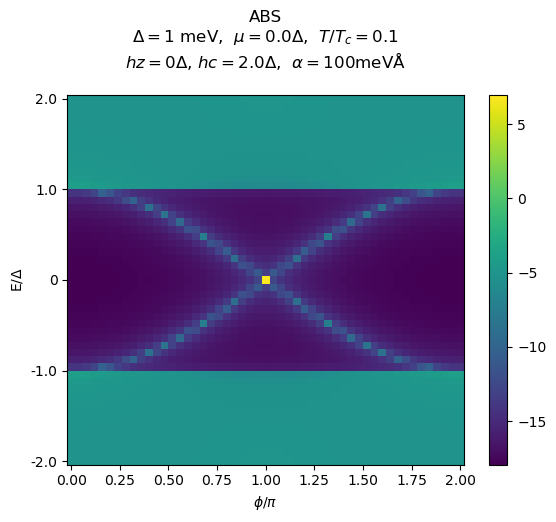

In [4]:
#ABS
num_ef = 50
efmin = -Delta*2
efmax = Delta*2
def_ = (efmax - efmin) / num_ef
num_phi = 50
phi_min = 0
phi_max = 2 * np.pi
dphi = (phi_max - phi_min) / num_phi

# Initialize grids
ef_plot = np.zeros(num_ef + 1)
phi_plot = np.zeros(num_phi + 1)
ABS = np.zeros((num_ef + 1, num_phi + 1))

for jj in range(num_ef + 1):
    ef = efmin + def_ * jj
    ef_plot[jj] = ef
    for ii in range(num_phi + 1):
        phi = phi_min + dphi * ii
        phi_plot[ii] = phi / np.pi
        
        # Update Delta and H_l, H_r based on phi
        H_r = H_onsite(h,hz,3,phi,saimanjiao)
        
        # Compute G_DD_r
        G_DD_r, _, _, _ = Gr_DD(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, ef
        )
        
        # Compute ABS (bufeng)
        ABS[jj, ii] = bufeng(G_DD_r)

# Figure
plt.figure()
X, Y = np.meshgrid(phi_plot, ef_plot)
plt.pcolormesh(X, Y, np.log(ABS + 1e-10), shading='auto')  # Added small epsilon to avoid log(0)
plt.colorbar(location='right')
plt.xlabel(r'$\phi$/$\pi$')

plt.ylabel('E/$\Delta$')
plt.yticks(
    [efmin, efmin/2, 0,efmax/2, efmax],
    [efmin/Delta, efmin*0.5/Delta, 0,efmax*0.5/Delta, efmax/Delta]
)
plt.title(
    f'ABS\n'
    f'$\\Delta = {dela}$ meV,  $\\mu = {mu/dela}\\Delta$,  $T/T_c = {T_Tc}$\n'
    f'$hz = {hz}\\Delta$, $hc = {h}\\Delta$,  $\\alpha = {af}$meVÅ\n'
    
)
plt.axis('square')
plt.axis('tight')
plt.show()

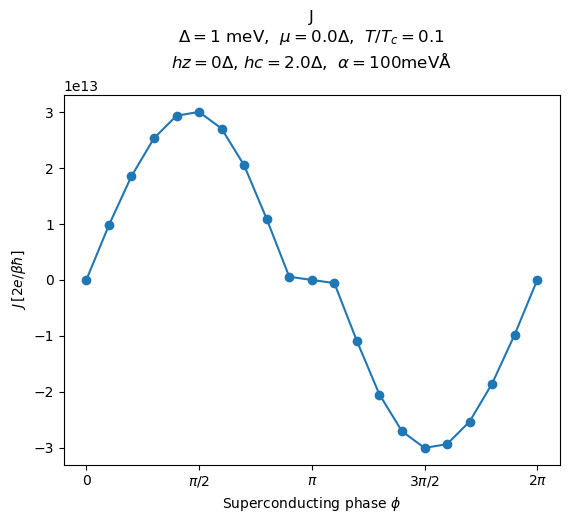

In [5]:
phi_list = np.linspace(0, 2*np.pi, 21)
J_list = []
for phi in phi_list:

    chaodaojiao = phi
    H_r = H_onsite(h,hz,3,chaodaojiao,saimanjiao)
    Jphi = J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N, q)

    J_list.append(Jphi)

plt.figure()
plt.plot(phi_list, J_list, marker='o')
plt.xlabel(r'Superconducting phase $\phi$')
plt.ylabel(r'$J\,[2e/\beta\hbar]$')
plt.xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
    ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
)
plt.title(
    f'J\n'
    f'$\\Delta = {dela}$ meV,  $\\mu = {mu/dela}\\Delta$,  $T/T_c = {T_Tc}$\n'
    f'$hz = {hz}\\Delta$, $hc = {h}\\Delta$,  $\\alpha = {af}$meVÅ\n'
    
)
plt.show()

